# AEGIS notebook

Project: AEGIS rebuild for reproducible wind anomaly, federated learning, and edge deployment evaluation.


In [1]:
import json
import pickle
import random
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, average_precision_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT = Path.cwd()
DATA_DIR   = ROOT / "data"
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
TABLES_DIR  = ROOT / "tables"

WIND_COMBINED_PATH     = DATA_DIR  / "processed" / "02_baseline_combined_dataset.csv"
WIND_MODEL_PATH        = MODELS_DIR / "03_best_autoencoder.keras"
WIND_SCALER_PATH       = MODELS_DIR / "03_standard_scaler.pkl"
WIND_TRAIN_ERRORS_PATH = RESULTS_DIR / "03_train_normal_reconstruction_errors.csv"
WIND_MEDIANS_PATH      = RESULTS_DIR / "03_train_normal_feature_medians.csv"
MAPPING_PATH           = TABLES_DIR  / "01_selected_feature_pairs.csv"
VESTAS_PATH            = DATA_DIR  / "Vestas_V52" / "VestasV52_10_min_raw_SCADA_DkIT 30_Jan2006-12_Mar2020.xlsx"

for p in [WIND_COMBINED_PATH, WIND_MODEL_PATH, WIND_SCALER_PATH,
          WIND_TRAIN_ERRORS_PATH, WIND_MEDIANS_PATH, MAPPING_PATH, VESTAS_PATH]:
    print(p, "->", p.exists())

C:\Users\MOINODHEEN\Moinu\AEGIS_Project\data\processed\02_baseline_combined_dataset.csv -> True
C:\Users\MOINODHEEN\Moinu\AEGIS_Project\models\03_best_autoencoder.keras -> True
C:\Users\MOINODHEEN\Moinu\AEGIS_Project\models\03_standard_scaler.pkl -> True
C:\Users\MOINODHEEN\Moinu\AEGIS_Project\results\03_train_normal_reconstruction_errors.csv -> True
C:\Users\MOINODHEEN\Moinu\AEGIS_Project\results\03_train_normal_feature_medians.csv -> True
C:\Users\MOINODHEEN\Moinu\AEGIS_Project\tables\01_selected_feature_pairs.csv -> True
C:\Users\MOINODHEEN\Moinu\AEGIS_Project\data\Vestas_V52\VestasV52_10_min_raw_SCADA_DkIT 30_Jan2006-12_Mar2020.xlsx -> True


In [2]:
def find_label_column(df):
    candidates = ["label", "anomaly_label", "target", "y", "is_anomaly", "class"]
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        cl = c.lower()
        if "label" in cl or "anomaly" in cl or cl == "target":
            return c
    raise ValueError("Could not find label column in wind combined dataset.")

def find_source_column(df):
    candidates = ["source", "dataset", "site", "origin", "farm", "location"]
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        cl = c.lower()
        if any(k in cl for k in ["source","dataset","site","origin","farm","location"]):
            return c
    return None

def detect_mapping_columns(df):
    cols  = list(df.columns)
    lower = {c: c.lower() for c in cols}
    wind_col, vestas_col = None, None
    for c in cols:
        if "wind"   in lower[c] and wind_col   is None: wind_col   = c
        if "vestas" in lower[c] and vestas_col is None: vestas_col = c
    if wind_col is None or vestas_col is None:
        if len(cols) >= 2:
            wind_col, vestas_col = cols[0], cols[1]
        else:
            raise ValueError("Mapping file must have at least two columns.")
    return wind_col, vestas_col

def build_autoencoder(input_dim):
    h1 = max(16, min(32, input_dim * 2))
    h2 = max(8,  min(16, input_dim))
    b  = max(4,  min(8,  input_dim // 2))
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(h1, activation="relu"),
        layers.Dense(h2, activation="relu"),
        layers.Dense(b,  activation="relu"),
        layers.Dense(h2, activation="relu"),
        layers.Dense(h1, activation="relu"),
        layers.Dense(input_dim, activation="linear")
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def reconstruction_errors(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_hat), axis=1)

def summarize_results(name, y_true, y_pred, scores, threshold, feature_count):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "scenario":           name,
        "feature_count":      int(feature_count),
        "threshold":          float(threshold),
        "precision":          float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":             float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":                 float(f1_score(y_true, y_pred, zero_division=0)),
        "pr_auc":             float(average_precision_score(y_true, scores)),
        "true_negatives":     int(tn),
        "false_positives":    int(fp),
        "false_negatives":    int(fn),
        "true_positives":     int(tp),
        "predicted_anomalies":int(np.sum(y_pred)),
        "actual_anomalies":   int(np.sum(y_true))
    }

In [6]:
wind_df    = pd.read_csv(WIND_COMBINED_PATH)
mapping_df = pd.read_csv(MAPPING_PATH)
vestas_df  = pd.read_excel(VESTAS_PATH)

label_col  = find_label_column(wind_df)
source_col = find_source_column(wind_df)

wind_map_col, vestas_map_col = detect_mapping_columns(mapping_df)
mapping_pairs = mapping_df[[wind_map_col, vestas_map_col]].dropna().copy()
mapping_pairs.columns = ["wind_feature", "vestas_feature"]
mapping_pairs["wind_feature"]   = mapping_pairs["wind_feature"].astype(str).str.strip()
mapping_pairs["vestas_feature"] = mapping_pairs["vestas_feature"].astype(str).str.strip()

# --- DIAGNOSTIC: show what source column contains ---
if source_col is not None:
    print(f"Source column found: '{source_col}'")
    print("Unique values in source column:", wind_df[source_col].unique()[:10])
else:
    print("No source column found.")

# --- Try source filter, but fall back to full dataset if result is empty ---
if source_col is not None:
    wind_mask    = wind_df[source_col].astype(str).str.lower().str.contains(
                       "wind farm a|farm a|wind", regex=True)
    wind_only_df = wind_df.loc[wind_mask].copy()
    if len(wind_only_df) == 0:
        print("WARNING: Source filter returned 0 rows. Using full dataset (all rows are Wind Farm A).")
        wind_only_df = wind_df.copy()
else:
    wind_only_df = wind_df.copy()

wind_only_df = wind_only_df.dropna(axis=0, how="all").copy()

numeric_vestas = vestas_df.select_dtypes(include=[np.number]).copy()
numeric_vestas = numeric_vestas.fillna(numeric_vestas.median(numeric_only=True))

wind_cols_clean   = pd.Index(wind_only_df.columns.astype(str)).str.strip()
vestas_cols_clean = pd.Index(numeric_vestas.columns.astype(str)).str.strip()

available_pairs = mapping_pairs[
    mapping_pairs["wind_feature"].isin(wind_cols_clean) &
    mapping_pairs["vestas_feature"].isin(vestas_cols_clean)
].drop_duplicates().reset_index(drop=True)

print("Matched feature pairs found:", len(available_pairs))

if len(available_pairs) < 3:
    print("DEBUG — Wind columns sample:", list(wind_only_df.columns[:10]))
    print("DEBUG — Mapping wind names:  ", mapping_pairs["wind_feature"].tolist())
    raise ValueError("Too few mapped features. Fix 01_selected_feature_pairs.csv.")

wind_features_mapped   = available_pairs["wind_feature"].tolist()
vestas_features_mapped = available_pairs["vestas_feature"].tolist()

power_candidates = [c for c in numeric_vestas.columns if "power" in c.lower()]
power_col        = power_candidates[0] if power_candidates else numeric_vestas.columns[0]

power_data = numeric_vestas[power_col]
z_scores   = np.abs((power_data - power_data.mean()) / power_data.std())
y_vestas   = (z_scores > 2.5).astype(int).values

wind_normals        = wind_only_df[wind_only_df[label_col] == 0].copy()
wind_normals_mapped = wind_normals[wind_features_mapped].copy()

vestas_mapped_raw           = numeric_vestas[vestas_features_mapped].copy()
vestas_mapped_raw.columns   = wind_features_mapped

print("Wind combined shape:  ", wind_df.shape)
print("Wind-only shape:      ", wind_only_df.shape)
print("Wind normal shape:    ", wind_normals.shape)
print("Vestas shape:         ", vestas_df.shape)
print("Mapped feature count: ", len(wind_features_mapped))
print("Power column used:    ", power_col)
print("Vestas anomaly count: ", int(y_vestas.sum()))
display(available_pairs)

Source column found: 'source_event'
Unique values in source column: [25 68 69 22]
Matched feature pairs found: 6
Wind combined shape:   (216919, 83)
Wind-only shape:       (216919, 83)
Wind normal shape:     (109525, 83)
Vestas shape:          (653103, 22)
Mapped feature count:  6
Power column used:     Power
Vestas anomaly count:  25700


,wind_feature,vestas_feature
0,feature_007,WindSpeed
1,feature_011,StdDevWindSpeed
2,feature_048,Power
3,feature_049,MaxPower
4,feature_050,MinPower
5,feature_051,StdDevPower


In [7]:
wind_model = keras.models.load_model(WIND_MODEL_PATH)

try:
    wind_scaler = joblib.load(WIND_SCALER_PATH)
except Exception:
    with open(WIND_SCALER_PATH, "rb") as f:
        wind_scaler = pickle.load(f)

train_err_df   = pd.read_csv(WIND_TRAIN_ERRORS_PATH)
train_err_col  = train_err_df.select_dtypes(include=[np.number]).columns[0]
wind_threshold_95 = np.percentile(train_err_df[train_err_col].values, 95)

medians_df       = pd.read_csv(WIND_MEDIANS_PATH)
median_feature_col = medians_df.columns[0]
wind_feature_order = medians_df[median_feature_col].astype(str).tolist()

# Build zero-filled input: all 0 except the 6 mapped columns
zero_fill_raw = pd.DataFrame(0.0,
                              index=np.arange(len(vestas_mapped_raw)),
                              columns=wind_feature_order)
for c in wind_features_mapped:
    if c in zero_fill_raw.columns:
        zero_fill_raw[c] = vestas_mapped_raw[c].values

X_zero_scaled  = wind_scaler.transform(zero_fill_raw[wind_feature_order])
zero_scores    = reconstruction_errors(wind_model, X_zero_scaled)
zero_preds     = (zero_scores > wind_threshold_95).astype(int)

zero_fill_result = summarize_results(
    "Zero-fill transfer (Wind model → Vestas)",
    y_vestas, zero_preds, zero_scores, wind_threshold_95, len(wind_feature_order)
)

zero_scores_df = pd.DataFrame({
    "y_true": y_vestas,
    "score":  zero_scores,
    "y_pred": zero_preds
})
zero_scores_path = RESULTS_DIR / "05_zero_fill_scores.csv"
zero_scores_df.to_csv(zero_scores_path, index=False)

display(pd.DataFrame([zero_fill_result]))
print(f"Saved: {zero_scores_path}")

,scenario,feature_count,threshold,precision,recall,f1,pr_auc,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies,actual_anomalies
0,Zero-fill transfer (Wind model → Vestas),81,0.021928,0.039351,1.0,0.075722,0.373146,0,627403,0,25700,653103,25700


Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\results\05_zero_fill_scores.csv


In [8]:
X_train_map, X_val_map = train_test_split(
    wind_normals_mapped, test_size=0.2, random_state=SEED
)

mapped_scaler    = StandardScaler()
X_train_map_s    = mapped_scaler.fit_transform(X_train_map)
X_val_map_s      = mapped_scaler.transform(X_val_map)
X_vestas_map_s   = mapped_scaler.transform(vestas_mapped_raw)

mapped_model = build_autoencoder(X_train_map_s.shape[1])

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_mapped = mapped_model.fit(
    X_train_map_s, X_train_map_s,
    validation_data=(X_val_map_s, X_val_map_s),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

mapped_train_scores   = reconstruction_errors(mapped_model, X_train_map_s)
mapped_threshold_95   = np.percentile(mapped_train_scores, 95)

mapped_scores = reconstruction_errors(mapped_model, X_vestas_map_s)
mapped_preds  = (mapped_scores > mapped_threshold_95).astype(int)

mapped_result = summarize_results(
    "Mapped-feature transfer (fair small model)",
    y_vestas, mapped_preds, mapped_scores, mapped_threshold_95, X_train_map_s.shape[1]
)

mapped_scores_df = pd.DataFrame({
    "y_true": y_vestas,
    "score":  mapped_scores,
    "y_pred": mapped_preds
})
mapped_scores_path = RESULTS_DIR / "05_mapped_feature_scores.csv"
mapped_scores_df.to_csv(mapped_scores_path, index=False)

mapped_model_path = MODELS_DIR / "05_mapped_feature_autoencoder.keras"
mapped_model.save(mapped_model_path)

with open(MODELS_DIR / "05_mapped_feature_scaler.pkl", "wb") as f:
    pickle.dump(mapped_scaler, f)

display(pd.DataFrame([mapped_result]))
print(f"Saved: {mapped_scores_path}")
print(f"Saved: {mapped_model_path}")

Epoch 1/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3878 - val_loss: 0.1284
Epoch 2/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0920 - val_loss: 0.0759
Epoch 3/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0746 - val_loss: 0.0674
Epoch 4/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0604 - val_loss: 0.0463
Epoch 5/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0368 - val_loss: 0.0288
Epoch 6/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0240 - val_loss: 0.0210
Epoch 7/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0183 - val_loss: 0.0171
Epoch 8/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0153 - val_loss: 0.0147
Epoch 9/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0136 - val_loss: 0.0132
Epoch 10/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0125 - val_loss: 0.0122
Epoch 11/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0116 - val_loss: 0.0115
Epoch 12/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

,scenario,feature_count,threshold,precision,recall,f1,pr_auc,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies,actual_anomalies
0,Mapped-feature transfer (fair small model),6,0.015469,0.039359,1.0,0.075736,0.894417,134,627269,0,25700,652969,25700


Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\results\05_mapped_feature_scores.csv
Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\models\05_mapped_feature_autoencoder.keras


In [9]:
transfer_results_df = pd.DataFrame([zero_fill_result, mapped_result])
transfer_results_df = transfer_results_df.sort_values("f1", ascending=False).reset_index(drop=True)

results_csv = RESULTS_DIR / "05_cross_site_transfer_results.csv"
tables_csv  = TABLES_DIR  / "05_cross_site_transfer_results.csv"

transfer_results_df.to_csv(results_csv, index=False)
transfer_results_df.to_csv(tables_csv,  index=False)

display(transfer_results_df)
print(f"Saved: {results_csv}")
print(f"Saved: {tables_csv}")

,scenario,feature_count,threshold,precision,recall,f1,pr_auc,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies,actual_anomalies
0,Mapped-feature transfer (fair small model),6,0.015469,0.039359,1.0,0.075736,0.894417,134,627269,0,25700,652969,25700
1,Zero-fill transfer (Wind model → Vestas),81,0.021928,0.039351,1.0,0.075722,0.373146,0,627403,0,25700,653103,25700


Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\results\05_cross_site_transfer_results.csv
Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\tables\05_cross_site_transfer_results.csv


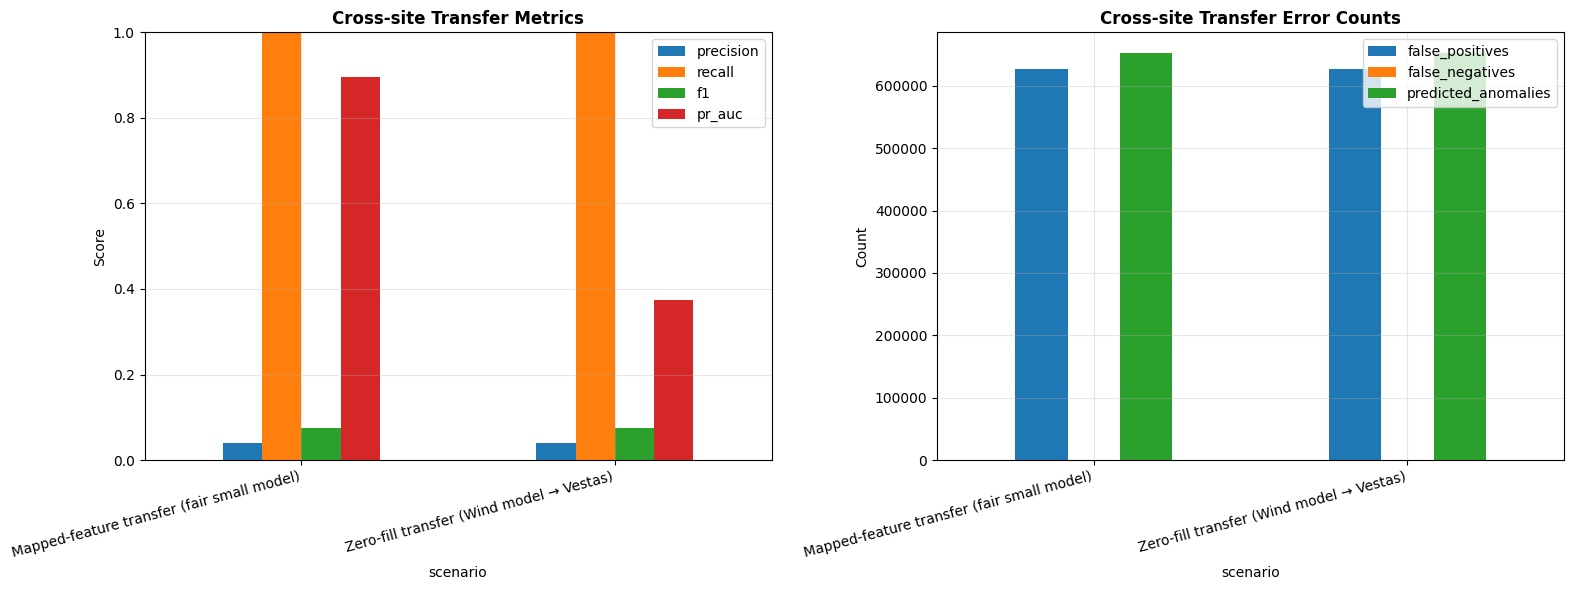

Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\figures\05_cross_site_transfer.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metric_cols = ["precision", "recall", "f1", "pr_auc"]
plot_df = transfer_results_df.set_index("scenario")[metric_cols]
plot_df.plot(kind="bar", ax=axes[0], rot=15)
axes[0].set_title("Cross-site Transfer Metrics", fontweight="bold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.0)
axes[0].grid(True, alpha=0.3)
for tick in axes[0].get_xticklabels():
    tick.set_ha("right")

count_cols = ["false_positives", "false_negatives", "predicted_anomalies"]
count_df = transfer_results_df.set_index("scenario")[count_cols]
count_df.plot(kind="bar", ax=axes[1], rot=15)
axes[1].set_title("Cross-site Transfer Error Counts", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)
for tick in axes[1].get_xticklabels():
    tick.set_ha("right")

plt.tight_layout()
fig_path = FIGURES_DIR / "05_cross_site_transfer.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

In [11]:
best_row = transfer_results_df.iloc[0]

summary_lines = [
    "Cross-Site Transfer Summary",
    "==========================",
    "",
    f"Best transfer scenario : {best_row['scenario']}",
    f"Feature count          : {int(best_row['feature_count'])}",
    f"Threshold              : {best_row['threshold']:.6f}",
    f"Precision              : {best_row['precision']:.6f}",
    f"Recall                 : {best_row['recall']:.6f}",
    f"F1-score               : {best_row['f1']:.6f}",
    f"PR-AUC                 : {best_row['pr_auc']:.6f}",
    f"False positives        : {int(best_row['false_positives'])}",
    f"False negatives        : {int(best_row['false_negatives'])}",
    "",
    "Interpretation:",
    "Zero-fill transfer tests robustness of the original Wind Farm A model under feature mismatch.",
    "Mapped-feature transfer tests whether a smaller fair model trained only on shared variables",
    "improves cross-site portability. These results will be compared with federated learning",
    "results in 06_federated_learning.ipynb to test whether collaborative training recovers",
    "part of the heterogeneity performance loss."
]

summary_text = "\n".join(summary_lines)
txt_path = RESULTS_DIR / "05_cross_site_transfer_summary.txt"
md_path  = RESULTS_DIR / "05_cross_site_transfer_summary.md"

with open(txt_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

with open(md_path, "w", encoding="utf-8") as f:
    f.write("## Cross-Site Transfer Summary\n\n")
    for line in summary_lines[3:]:
        f.write(line + "\n")

print(summary_text)
print(f"\nSaved: {txt_path}")
print(f"Saved: {md_path}")

Cross-Site Transfer Summary

Best transfer scenario : Mapped-feature transfer (fair small model)
Feature count          : 6
Threshold              : 0.015469
Precision              : 0.039359
Recall                 : 1.000000
F1-score               : 0.075736
PR-AUC                 : 0.894417
False positives        : 627269
False negatives        : 0

Interpretation:
Zero-fill transfer tests robustness of the original Wind Farm A model under feature mismatch.
Mapped-feature transfer tests whether a smaller fair model trained only on shared variables
improves cross-site portability. These results will be compared with federated learning
results in 06_federated_learning.ipynb to test whether collaborative training recovers
part of the heterogeneity performance loss.

Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\results\05_cross_site_transfer_summary.txt
Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\results\05_cross_site_transfer_summary.md


In [13]:
import pandas as pd
from pathlib import Path

transfer_path = Path("tables/05_cross_site_transfer_results.csv")
if not transfer_path.exists():
    raise FileNotFoundError("Missing tables/05_cross_site_transfer_results.csv")

transfer_df = pd.read_csv(transfer_path)

print("Loaded:", transfer_path)
print("Shape:", transfer_df.shape)
print("\nColumns:")
print(list(transfer_df.columns))

transfer_df.head()

Loaded: tables\05_cross_site_transfer_results.csv
Shape: (2, 13)

Columns:
['scenario', 'feature_count', 'threshold', 'precision', 'recall', 'f1', 'pr_auc', 'true_negatives', 'false_positives', 'false_negatives', 'true_positives', 'predicted_anomalies', 'actual_anomalies']


,scenario,feature_count,threshold,precision,recall,f1,pr_auc,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies,actual_anomalies
0,Mapped-feature transfer (fair small model),6,0.015469,0.039359,1.0,0.075736,0.894417,134,627269,0,25700,652969,25700
1,Zero-fill transfer (Wind model → Vestas),81,0.021928,0.039351,1.0,0.075722,0.373146,0,627403,0,25700,653103,25700


In [14]:
import json

with open("results/03_local_autoencoder_metrics.json", "r") as f:
    local_baseline = json.load(f)

local_baseline

{'model_name': 'deep_b32',
 'hidden_layers': '[64, 32]',
 'bottleneck': 32,
 'dropout': 0.0,
 'l2_reg': 1e-05,
 'fit_time_seconds': 55.6151,
 'epochs_run': 50,
 'parameter_count': 16817,
 'threshold': 0.021927732974572938,
 'precision': 0.8839647119875454,
 'recall': 0.3965268401694679,
 'f1': 0.5474705920164556,
 'roc_auc': 0.7232721525966892,
 'pr_auc': 0.7500663670107532,
 'tn': 20787,
 'fp': 1118,
 'fn': 12962,
 'tp': 8517,
 'predicted_anomalies': 9635,
 'train_normal_rows': 87620,
 'test_rows': 43384,
 'input_dim': 81}

In [15]:
for col in transfer_df.columns:
    print(col, "-> sample values:", transfer_df[col].dropna().astype(str).head(5).tolist())

scenario -> sample values: ['Mapped-feature transfer (fair small model)', 'Zero-fill transfer (Wind model → Vestas)']
feature_count -> sample values: ['6', '81']
threshold -> sample values: ['0.0154691787971024', '0.0219277329745729']
precision -> sample values: ['0.0393586831840409', '0.0393506077908078']
recall -> sample values: ['1.0', '1.0']
f1 -> sample values: ['0.0757364783126973', '0.0757215274534732']
pr_auc -> sample values: ['0.8944172389344893', '0.3731463995106695']
true_negatives -> sample values: ['134', '0']
false_positives -> sample values: ['627269', '627403']
false_negatives -> sample values: ['0', '0']
true_positives -> sample values: ['25700', '25700']
predicted_anomalies -> sample values: ['652969', '653103']
actual_anomalies -> sample values: ['25700', '25700']


In [16]:
import pandas as pd
from pathlib import Path

Path("tables").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

local_row = pd.DataFrame([{
    "scenario": "Local baseline (Wind Farm A)",
    "feature_count": local_baseline.get("input_dim"),
    "threshold": local_baseline.get("threshold"),
    "precision": local_baseline.get("precision"),
    "recall": local_baseline.get("recall"),
    "f1": local_baseline.get("f1"),
    "pr_auc": local_baseline.get("pr_auc"),
    "true_negatives": local_baseline.get("tn"),
    "false_positives": local_baseline.get("fp"),
    "false_negatives": local_baseline.get("fn"),
    "true_positives": local_baseline.get("tp"),
    "predicted_anomalies": local_baseline.get("predicted_anomalies"),
    "actual_anomalies": None
}])

comparison_df = pd.concat([local_row, transfer_df], ignore_index=True)
comparison_df.to_csv("tables/05_cross_site_transfer_comparison.csv", index=False)
comparison_df

,scenario,feature_count,threshold,precision,recall,f1,pr_auc,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies,actual_anomalies
0,Local baseline (Wind Farm A),81,0.021928,0.883965,0.396527,0.547471,0.750066,20787,1118,12962,8517,9635,None
1,Mapped-feature transfer (fair small model),6,0.015469,0.039359,1.000000,0.075736,0.894417,134,627269,0,25700,652969,25700
2,Zero-fill transfer (Wind model → Vestas),81,0.021928,0.039351,1.000000,0.075722,0.373146,0,627403,0,25700,653103,25700


In [17]:
base_precision = float(local_baseline["precision"])
base_recall = float(local_baseline["recall"])
base_f1 = float(local_baseline["f1"])
base_pr_auc = float(local_baseline["pr_auc"])

delta_df = transfer_df.copy()
delta_df["delta_precision_vs_local"] = delta_df["precision"] - base_precision
delta_df["delta_recall_vs_local"] = delta_df["recall"] - base_recall
delta_df["delta_f1_vs_local"] = delta_df["f1"] - base_f1
delta_df["delta_pr_auc_vs_local"] = delta_df["pr_auc"] - base_pr_auc

delta_df.to_csv("tables/05_cross_site_transfer_delta_vs_local.csv", index=False)
delta_df

,scenario,feature_count,threshold,precision,recall,f1,pr_auc,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies,actual_anomalies,delta_precision_vs_local,delta_recall_vs_local,delta_f1_vs_local,delta_pr_auc_vs_local
0,Mapped-feature transfer (fair small model),6,0.015469,0.039359,1.0,0.075736,0.894417,134,627269,0,25700,652969,25700,-0.844606,0.603473,-0.471734,0.144351
1,Zero-fill transfer (Wind model → Vestas),81,0.021928,0.039351,1.0,0.075722,0.373146,0,627403,0,25700,653103,25700,-0.844614,0.603473,-0.471749,-0.376920


In [18]:
report_df = comparison_df[[
    "scenario", "feature_count", "threshold",
    "precision", "recall", "f1", "pr_auc",
    "false_positives", "false_negatives"
]].copy()

for c in ["threshold", "precision", "recall", "f1", "pr_auc"]:
    report_df[c] = report_df[c].astype(float).round(6)

report_df.to_csv("tables/05_cross_site_transfer_report_table.csv", index=False)
report_df

,scenario,feature_count,threshold,precision,recall,f1,pr_auc,false_positives,false_negatives
0,Local baseline (Wind Farm A),81,0.021928,0.883965,0.396527,0.547471,0.750066,1118,12962
1,Mapped-feature transfer (fair small model),6,0.015469,0.039359,1.000000,0.075736,0.894417,627269,0
2,Zero-fill transfer (Wind model → Vestas),81,0.021928,0.039351,1.000000,0.075722,0.373146,627403,0


In [19]:
best_transfer_idx = transfer_df["f1"].idxmax()
best_transfer = transfer_df.loc[best_transfer_idx]

summary_lines = [
    "Cross-Site Transfer Summary",
    "==========================",
    "",
    f"Local baseline F1: {local_baseline['f1']:.6f}",
    f"Best transfer scenario: {best_transfer['scenario']}",
    f"Transfer F1: {best_transfer['f1']:.6f}",
    f"Transfer precision: {best_transfer['precision']:.6f}",
    f"Transfer recall: {best_transfer['recall']:.6f}",
    f"Transfer PR-AUC: {best_transfer['pr_auc']:.6f}",
    "",
    "Interpretation:",
    "Cross-site transfer to Vestas shows severe precision collapse despite perfect recall.",
    "This indicates strong domain mismatch and supports the need for adaptation or federated learning."
]

Path("results").mkdir(exist_ok=True)
with open("results/05_cross_site_transfer_summary.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))

with open("results/05_cross_site_transfer_summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))

print("Saved: results/05_cross_site_transfer_summary.txt")
print("Saved: results/05_cross_site_transfer_summary.md")

Saved: results/05_cross_site_transfer_summary.txt
Saved: results/05_cross_site_transfer_summary.md
